# 3D coupling, separation, and outcome




In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
PACKAGE_ROOT = next(
    path for path in [cwd, *cwd.parents]
    if (path / 'data').exists() and (path / 'src').exists()
    and (path / 'notebooks').exists()
)
sys.path.insert(0, str(PACKAGE_ROOT))

from src.analysis.fragility import (
    distance_outcome_summary, fit_curves_by_fire, partial_damage_summary,
)
from src.analysis.openview_3d_sen import (
    load_county_buildings, prepare_openview_3d_distance_comparison,
)
from src.viz.figure1 import (
    plot_distance_comparison, plot_fragility, plot_partial_damage,
)
from src.viz.style import apply_style
# Everything here is exploratory except the a-h composite, which is Figure 2.
from src.figure_paths import figure_dir, save_figure

apply_style()
EXPLORATORY = figure_dir('exploratory')
MAIN = figure_dir('main')
OPENVIEW_3D_RUN = Path(os.environ.get(
    'OPENVIEW_3D_BVF_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/lariac6_wui_all_2mi_bvf_3d_nf_cone85_nosolar',
))
# The county run keeps building-level edges only; patch-level exchange (for
# the visible-surface distance and the Figure 1 example) comes from a
# fire-area companion run with the same configuration.
OPENVIEW_PATCH_RUN = Path(os.environ.get(
    'OPENVIEW_3D_PATCH_DIR',
    '/Users/adamswietek/Documents/PostDoc/openview/results/fires_eaton_palisades_800m_bvf_3d_nf_cone85_nosolar_patches',
))
DERIVED = PACKAGE_ROOT / 'data' / 'derived' / 'openview3d_lariac6_2mi'
ANALYSIS_PATH = DERIVED / 'analysis_openview3d.parquet'
BUILDING_CACHE = DERIVED / 'county_buildings.parquet'
DISTANCE_CACHE = DERIVED / 'distance_comparison_openview3d.parquet'

REBUILD_SSD = False

## Distance definitions

- **CCD** is centroid-to-centroid distance to the nearest other DINS-destroyed building in the same fire.
- **SSD** is the shortest 3D distance from a focal facade patch to a visible facade patch on a DINS-destroyed building in the same fire. It is derived from `patch_exchange.parquet`.
- $F^*$ is the summed directional receiver view factor from DINS-destroyed neighbors (`F_destroyed_wmean`).
- **Survived** is the original figure's binary complement of destroyed: both no-damage and partially damaged assessed buildings.

In [2]:
analysis = pd.read_parquet(ANALYSIS_PATH)
buildings = load_county_buildings(OPENVIEW_3D_RUN, BUILDING_CACHE)
distance_data = prepare_openview_3d_distance_comparison(
    OPENVIEW_3D_RUN, buildings, analysis, DISTANCE_CACHE,
    rebuild=REBUILD_SSD, patch_run_dir=OPENVIEW_PATCH_RUN,
)
assert distance_data.graph_id.is_unique
print(f'Assessed structures: {len(distance_data):,}')
print(f'CCD coverage: {distance_data.ccd_ft.notna().mean():.1%}')
print(f'Visible destroyed-surface SSD coverage: {distance_data.ssd_ft.notna().mean():.1%}')

Assessed structures: 28,257
CCD coverage: 100.0%
Visible destroyed-surface SSD coverage: 85.9%


In [3]:
coverage = (
    distance_data.assign(
        plotted_ccd=lambda x: x.ccd_ft.gt(0) & x.F_destroyed_wmean.gt(0),
        plotted_ssd=lambda x: x.ssd_ft.gt(0) & x.F_destroyed_wmean.gt(0),
    )
    .groupby(['fire', 'outcome'], observed=True)
    .agg(n=('graph_id', 'size'), plotted_ccd=('plotted_ccd', 'sum'),
         plotted_ssd=('plotted_ssd', 'sum'))
)
display(coverage)

n  plotted_ccd  plotted_ssd
fire      outcome                                  
EATON     destroyed  8596         8553         8553
          no_damage  7270         4724         4724
          partial    1002          939          939
PALISADES destroyed  6529         6443         6440
          no_damage  3936         2753         2753
          partial     924          865          864

## CCD and SSD versus realized coupling

Points are geometric means within pooled log-distance quantile bins; vertical bars are 95% intervals for mean log coupling. Curves are LOWESS fits to those binned points. The annotated outcome gap is the mean destroyed-to-surviving median $F^*$ ratio within matched distance bins.

,distance_measure,destroyed_to_surviving_F_star_ratio
0,CCD,1.919
1,SSD,1.577


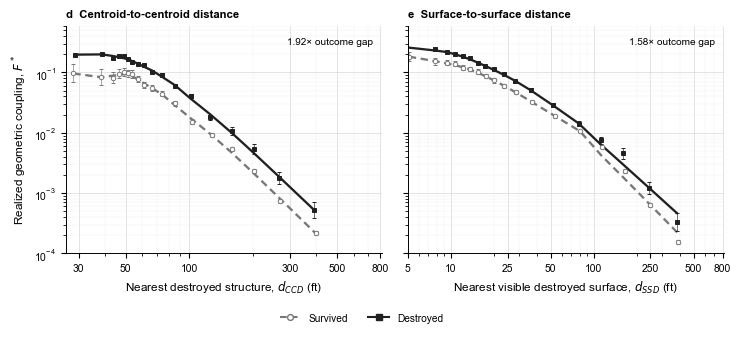

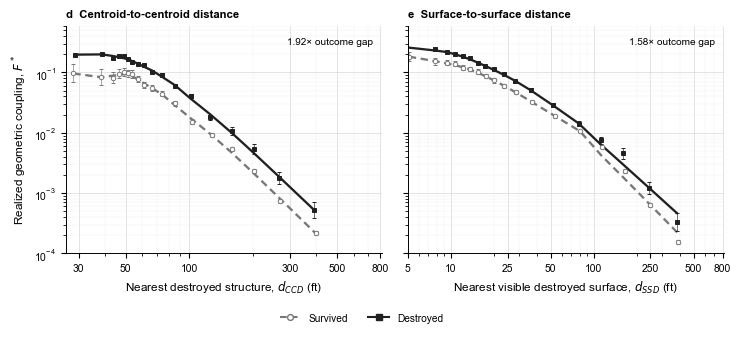

In [4]:
distance_summaries = {
    measure: distance_outcome_summary(distance_data, measure)
    for measure in ('ccd_ft', 'ssd_ft')
}
distance_gap = pd.DataFrame([
    {
        'distance_measure': measure.removesuffix('_ft').upper(),
        'destroyed_to_surviving_F_star_ratio': summary[2],
    }
    for measure, summary in distance_summaries.items()
])
distance_gap.to_csv(DERIVED / 'distance_outcome_gap_openview3d.csv', index=False)
display(distance_gap.round(3))
fig = plot_distance_comparison(
    distance_summaries, EXPLORATORY, DERIVED,
    panel_labels=('d', 'e'), stem='ccd_ssd_vs_F_openview3d',
)
fig

## Structural fragility from the new 3D run

A five-parameter logistic curve is fitted separately for Eaton and Palisades using the exposed DINS-assessed structures and their new OpenView 3D realized coupling, $F^*$. The plotted points are empirical destruction proportions in ten equal-count $F^*$ bins with Wilson 95% intervals. $F_{50}$ is the coupling at the midpoint between the fitted lower and upper asymptotes; its 95% interval, and the cross-fire $F_{50}$ ratio interval, come from resampling approximately 250 m spatial blocks (`grid_id`).

,fire,outcome,n,p_min,p_max,k,hill,asymmetry,f50,f50_lo,f50_hi
0,EATON,destroyed,14216,0.02238,0.97174,0.04978,1.93636,0.62713,0.03463,0.03193,0.03766
1,PALISADES,destroyed,10061,0.07562,0.99782,0.11371,2.14618,0.30067,0.04079,0.03414,0.04585


Palisades:Eaton destruction F50 ratio = 1.178 (95% spatial-block CI 0.970–1.356; 200 successful draws)


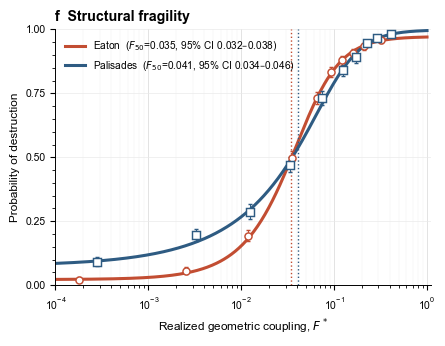

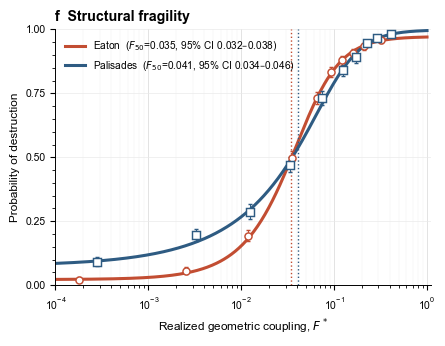

In [5]:
N_BOOT = int(os.environ.get('OPENVIEW_FRAGILITY_BOOTSTRAPS', '200'))
SEED = 0

required = {'fire', 'exposed', 'is_destroyed', 'grid_id', 'F_destroyed_wmean'}
missing = required.difference(analysis.columns)
if missing:
    raise ValueError(f'Analysis table is missing fragility fields: {sorted(missing)}')

destroyed_fits, destroyed_parameters, destroyed_draws = fit_curves_by_fire(
    analysis, 'is_destroyed', n_boot=N_BOOT, seed=SEED,
)
destroyed_parameters['outcome'] = 'destroyed'
destroyed_ratio = (
    destroyed_fits['PALISADES']['f50'] / destroyed_fits['EATON']['f50']
)
destroyed_ratio_ci = np.percentile(
    destroyed_draws.ratio_PAL_to_EAT, [2.5, 97.5],
)

destroyed_parameters.to_csv(
    DERIVED / 'fragility_parameters_openview3d.csv', index=False,
)
destroyed_draws.to_csv(
    DERIVED / 'fragility_spatial_bootstrap_draws_openview3d.csv', index=False,
)
display(destroyed_parameters.round(5))
print(
    f'Palisades:Eaton destruction F50 ratio = {destroyed_ratio:.3f} '
    f'(95% spatial-block CI {destroyed_ratio_ci[0]:.3f}–'
    f'{destroyed_ratio_ci[1]:.3f}; {len(destroyed_draws)} successful draws)'
)
fragility_fig = plot_fragility(
    analysis, destroyed_fits, EXPLORATORY, DERIVED,
    panel_label='f', stem='fragility_openview3d',
)
fragility_fig

## Reading $F_{50}$ back as a separation

The fragility threshold is in units of realized coupling, which carries no intuitive scale. Both fires are pooled into one empirical relation between separation and realized coupling — geometric-mean $F^*$ in log-spaced distance bins over every exposed structure — and each fitted $F_{50}$ is read back through it as the separation that delivers that exposure.

Only the decreasing branch beyond the near-field peak is inverted: inside it the relation is not monotone, so an exposure does not identify a single separation. The calibration and the fragility fit are resampled together on the same 250 m spatial blocks, so the interval carries both the curve's uncertainty and the threshold's. The result is descriptive, not a setback rule: it states the separation at which the observed structures accumulated the threshold exposure in these two fires, with their fabric, wind and defensive actions.

In [ ]:
# Pooled empirical distance calibration: the separation that delivers F50.
# The fragility curve is in units of realized coupling, which has no intuitive
# scale. Both fires are pooled into one empirical F*-versus-distance relation,
# and each fitted F50 is read back through it as an equivalent separation.
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

CALIBRATION_BINS = 18
MEASURE_LABELS = {'ccd_ft': 'Centroid-to-centroid',
                  'ssd_ft': 'Visible surface-to-surface'}
MEASURE_TICKS = {'ccd_ft': [30, 50, 100, 200, 400],
                 'ssd_ft': [5, 10, 25, 50, 100, 250]}
FIRE_STYLE = {'EATON': ('#C24D32', (5, 5)), 'PALISADES': ('#2E5B82', (5, -10))}

paired_distance = (
    analysis.loc[analysis.exposed.eq(1) & analysis.F_destroyed_wmean.gt(0),
                 ['graph_id', 'grid_id', 'F_destroyed_wmean']]
    .merge(distance_data[['graph_id', 'ccd_ft', 'ssd_ft']], on='graph_id',
           validate='one_to_one')
)


def pooled_calibration(sample, measure, bins=CALIBRATION_BINS):
    """Geometric-mean F* per log-spaced distance bin, both fires pooled.

    Only the decreasing branch beyond the near-field peak is returned: below
    it the relation is not monotone, so an exposure does not identify one
    separation.
    """
    rows = sample.loc[sample[measure].gt(0),
                      [measure, 'F_destroyed_wmean']].dropna()
    edges = np.geomspace(rows[measure].quantile(.01),
                         rows[measure].quantile(.99), bins + 1)
    binned = rows.groupby(pd.cut(rows[measure], edges), observed=False)
    table = pd.DataFrame({
        'distance_ft': np.sqrt(edges[:-1] * edges[1:]),
        'F_star': binned.F_destroyed_wmean.apply(
            lambda values: np.exp(np.log(values).mean())
            if len(values) > 20 else np.nan).to_numpy(),
        'structures': binned.size().to_numpy(),
    }).dropna(subset=['F_star'])
    # Resampling can leave a bin that ticks back up, so the branch is made
    # strictly decreasing before it is inverted.
    branch = table.loc[table.F_star.idxmax():].copy()
    branch['F_star'] = branch.F_star.cummin()
    return branch.loc[branch.F_star.diff().fillna(-1.) < 0]


def equivalent_distance(table, f_star):
    """Separation at which the pooled relation reaches a given exposure."""
    if not table.F_star.min() <= f_star <= table.F_star.max():
        return np.nan
    curve = PchipInterpolator(np.log10(table.F_star.to_numpy()[::-1]),
                              np.log10(table.distance_ft.to_numpy()[::-1]))
    return float(10 ** curve(np.log10(f_star)))


calibration_curves = {measure: pooled_calibration(paired_distance, measure)
                      for measure in MEASURE_LABELS}
fitted_f50 = {fire: float(fit['f50']) for fire, fit in destroyed_fits.items()}
fitted_f50['Pooled'] = float(np.exp(np.mean(np.log(list(fitted_f50.values())))))

# The calibration and the fragility fit are resampled together on the same
# 250 m spatial blocks, so the interval carries both sources of uncertainty.
rng = np.random.default_rng(SEED)
blocks = paired_distance.grid_id.unique()
by_block = paired_distance.set_index('grid_id')
draw_distances = {(measure, fire): [] for measure in MEASURE_LABELS
                  for fire in fitted_f50}
for draw in destroyed_draws.itertuples():
    resample = by_block.loc[
        rng.choice(blocks, size=len(blocks), replace=True)
    ].reset_index()
    drawn_f50 = {'EATON': draw.EATON_f50, 'PALISADES': draw.PALISADES_f50}
    drawn_f50['Pooled'] = float(np.exp(np.mean(np.log(list(drawn_f50.values())))))
    for measure in MEASURE_LABELS:
        table = pooled_calibration(resample, measure)
        for fire, value in drawn_f50.items():
            draw_distances[(measure, fire)].append(
                equivalent_distance(table, value))

calibration_rows = []
for measure, label in MEASURE_LABELS.items():
    for fire, f50 in fitted_f50.items():
        draws = np.asarray(draw_distances[(measure, fire)], dtype=float)
        draws = draws[np.isfinite(draws)]
        calibration_rows.append({
            'measure': measure, 'measure_label': label, 'fire': fire,
            'f50': f50,
            'equivalent_distance_ft': equivalent_distance(
                calibration_curves[measure], f50),
            'ci_lo_ft': float(np.percentile(draws, 2.5)) if len(draws) else np.nan,
            'ci_hi_ft': float(np.percentile(draws, 97.5)) if len(draws) else np.nan,
            'draws': len(draws),
        })
f50_distance_calibration = pd.DataFrame(calibration_rows)
f50_distance_calibration.to_csv(
    DERIVED / 'f50_distance_calibration_openview3d.csv', index=False,
)
pd.concat([table.assign(measure=measure)
           for measure, table in calibration_curves.items()]).to_csv(
    DERIVED / 'f50_distance_calibration_curve_openview3d.csv', index=False,
)

fig_calibration, axes_calibration = plt.subplots(
    1, 2, figsize=(7.2, 3.0), sharey=True,
)
for ax, (measure, label) in zip(axes_calibration, MEASURE_LABELS.items()):
    table = calibration_curves[measure]
    grid = np.geomspace(table.distance_ft.min(), table.distance_ft.max(), 200)
    curve = PchipInterpolator(np.log10(table.distance_ft.to_numpy()),
                              np.log10(table.F_star.to_numpy()))
    ax.plot(grid, 10 ** curve(np.log10(grid)), color='#333333', lw=1.4, zorder=3)
    ax.plot(table.distance_ft, table.F_star, 'o', ms=3.2, mfc='white',
            mec='#333333', mew=.8, zorder=4)
    for fire, (colour, offset) in FIRE_STYLE.items():
        feet = f50_distance_calibration.loc[
            f50_distance_calibration.measure.eq(measure)
            & f50_distance_calibration.fire.eq(fire)
        ].iloc[0]
        ax.axhline(feet.f50, color=colour, lw=.8, ls=(0, (2.4, 1.6)), zorder=2)
        ax.plot([feet.equivalent_distance_ft], [feet.f50], 'o', ms=4.4,
                color=colour, zorder=5)
        ax.annotate(f'{fire.title()}  {feet.equivalent_distance_ft:.0f} ft',
                    (feet.equivalent_distance_ft, feet.f50), xytext=offset,
                    textcoords='offset points', fontsize=6.6, color=colour)
    ax.set(xscale='log', yscale='log', xlabel=f'{label} separation (ft)')
    ax.set_xticks(MEASURE_TICKS[measure])
    ax.set_xticklabels([str(tick) for tick in MEASURE_TICKS[measure]])
    ax.xaxis.set_minor_locator(plt.matplotlib.ticker.FixedLocator([]))
    ax.grid(alpha=.18, lw=.5)
    ax.spines[['top', 'right']].set_visible(False)
axes_calibration[0].set_ylabel(r'Realized geometric coupling, $F^*$')
fig_calibration.suptitle(
    'Pooled empirical calibration of $F_{50}$ to separation', fontsize=9,
)
fig_calibration.tight_layout()
calibration_stem = save_figure(
    fig_calibration, 'f50_distance_calibration_openview3d', 'exploratory',
)

display(f50_distance_calibration.round(
    {'f50': 4, 'equivalent_distance_ft': 1, 'ci_lo_ft': 1, 'ci_hi_ft': 1}))
for row in f50_distance_calibration.itertuples():
    print(f'{row.measure_label:<28} {row.fire:<10} F50={row.f50:.4f} -> '
          f'{row.equivalent_distance_ft:5.1f} ft '
          f'(95% block CI {row.ci_lo_ft:.1f}-{row.ci_hi_ft:.1f})')
fig_calibration

## Damage without total destruction

The partial-damage curve is the fitted probability of any damage minus the fitted probability of complete destruction. Each component is a fire-specific five-parameter logistic fit over the same exposed population. Points show the observed partial-damage proportion in ten equal-count $F^*$ bins with Wilson 95% intervals; dotted lines mark the fitted peak partial-damage coupling.

,fire,outcome,n,p_min,p_max,k,hill,asymmetry,f50,f50_lo,f50_hi
0,EATON,any_damage,14216,0.04616,0.98417,0.05258,2.46842,0.37338,0.02655,0.02428,0.02936
1,PALISADES,any_damage,10061,0.08492,0.99356,0.09981,3.04886,0.14431,0.02071,0.01532,0.02542


,fire,peak_partial_probability,peak_F_star
0,EATON,0.11866,0.03550
1,PALISADES,0.15936,0.02556


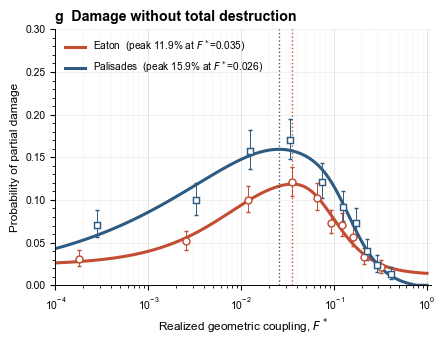

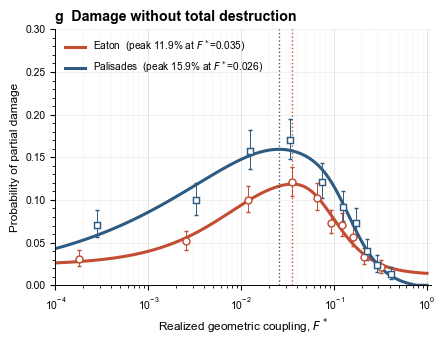

In [6]:
required_partial = {'any_damage', 'outcome'}
missing_partial = required_partial.difference(analysis.columns)
if missing_partial:
    raise ValueError(
        f'Analysis table is missing partial-damage fields: {sorted(missing_partial)}'
    )

exposed = analysis[analysis.exposed.eq(1)]
any_damage_fits, any_damage_parameters, any_damage_draws = fit_curves_by_fire(
    analysis, 'any_damage', n_boot=N_BOOT, seed=SEED,
)
any_damage_parameters['outcome'] = 'any_damage'
partial_peaks = partial_damage_summary(
    destroyed_fits, any_damage_fits,
    x_min=exposed.F_destroyed_wmean.min(),
    x_max=exposed.F_destroyed_wmean.max(),
)

any_damage_parameters.to_csv(
    DERIVED / 'any_damage_fragility_parameters_openview3d.csv', index=False,
)
any_damage_draws.to_csv(
    DERIVED / 'any_damage_spatial_bootstrap_draws_openview3d.csv', index=False,
)
partial_peaks.to_csv(
    DERIVED / 'partial_damage_summary_openview3d.csv', index=False,
)
display(any_damage_parameters.round(5))
display(partial_peaks.round(5))
partial_damage_fig = plot_partial_damage(
    analysis, destroyed_fits, any_damage_fits, partial_peaks,
    EXPLORATORY, DERIVED, panel_label='g', stem='partial_damage_openview3d',
)
partial_damage_fig

## Assemble paper-ready Main Figure 1

The composite uses the current OpenView 3D coupling analysis throughout. The compact **a-d** sequence first compares centroid and surface separation, then moves from pairwise facade-patch coupling to cumulative exposure across destroyed emitting neighbors. Panels **e-h** replay the frozen OpenView 3D distance and fragility source tables generated above. Typography and spacing are fixed at the final 180-mm publication width.

In [7]:
from src.viz.figure1_composite import build_figure1

PAPER_FIGURES = MAIN

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rank,emitter,F_ij,has_contact
0,1,1989387,0.0117,False
1,2,1989374,0.0052,False
2,3,2050140,0.0046,False


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/Users/adamswietek/Documents/PostDoc/wildfire/reviewer_reproduction/figures/s2s_nc/main/Fig1_geometric_coupling_and_fragility.pdf


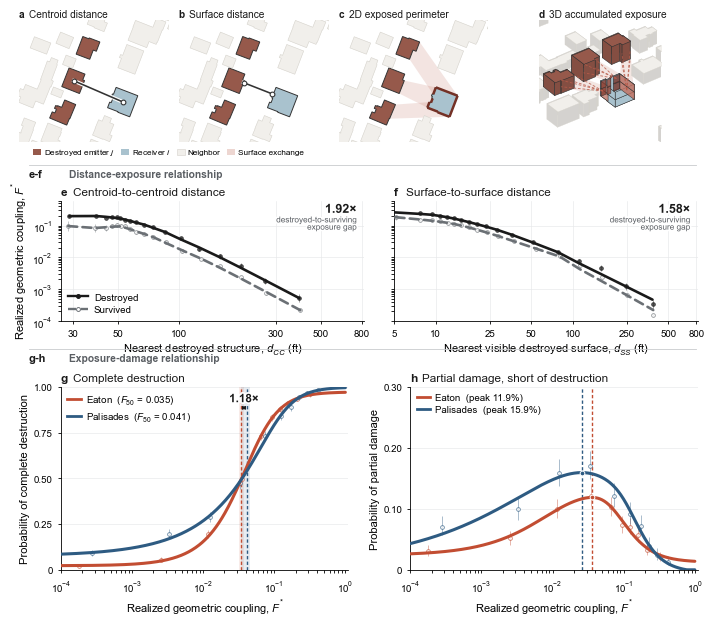

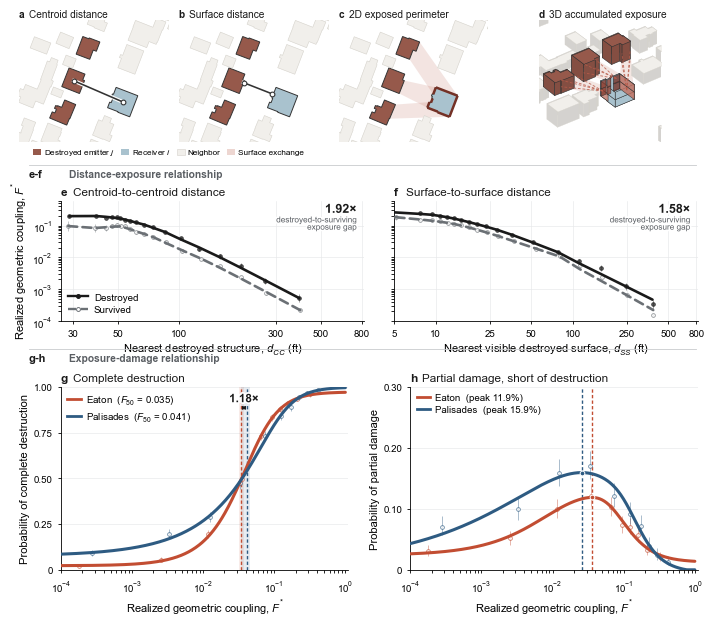

In [8]:
# Figure 1a-d: an observed Eaton pair across a street, then its three strongest contributors
from src.viz.figure1_eaton_example import build_eaton_geometry_panels
import matplotlib.pyplot as plt
receiver_id = '514984892555'
street_emitter_id = '514898892588'
fig_ad, building, neighbors = build_eaton_geometry_panels(
    OPENVIEW_3D_RUN, BUILDING_CACHE, ANALYSIS_PATH, EXPLORATORY,
    receiver_id=receiver_id, primary_emitter_id=street_emitter_id,
    patch_run_dir=OPENVIEW_PATCH_RUN,
)

display(neighbors[['rank', 'emitter', 'F_ij', 'has_contact']].round(4))
plt.close(fig_ad)

# Assemble the observed geometry panels with the distance and fragility panels.
# Reload so a long-lived kernel picks up the current row and composite code.
import importlib

import src.viz.figure1_measures
import src.viz.figure1_perimeter_2d
import src.viz.figure1_composite

for module in (src.viz.figure1_perimeter_2d, src.viz.figure1_measures,
               src.viz.figure1_composite):
    importlib.reload(module)
build_figure1 = src.viz.figure1_composite.build_figure1

main_figure_1 = build_figure1(
    DERIVED, DERIVED, MAIN,
    stem='Fig2_geometric_coupling_and_fragility',
    data_variant='openview3d',
    openview_run=OPENVIEW_3D_RUN,
    building_cache=BUILDING_CACHE,
    analysis_path=ANALYSIS_PATH,
    receiver_id=receiver_id,
    primary_emitter_id=street_emitter_id,
    scene_2d_run=PACKAGE_ROOT / 'data' / 'derived' / 'openview2d_eaton_scene',
    openview_patch_run=OPENVIEW_PATCH_RUN,
)
print(MAIN / 'Fig2_geometric_coupling_and_fragility.pdf')
main_figure_1

## Figure 1a-d: from distance to surface exposure

One Eaton scene carries all four panels, so the progression is literal: the same footprints are measured by centroid separation (a), by surface separation (b), by the share of the receiver perimeter that destroyed neighbours can see in 2D (c), and by accumulated exposure on the extruded facades in 3D (d). Panels a-b are the conventional distance-based measures; c-d are the surface-based ones.

Panel c reads the small LARIAC-footprint 2D graph built by `scripts/build_eaton_scene_2d.py`; panel d reads the 3D run's facade patches and shades each receiver facade by the exposure it accumulates from the destroyed emitters. The statewide 2D graph is built on OSM footprints, which omit several structures next to this receiver, which is why the local graph is used instead.

In [9]:
display(summary_2d.T.rename(columns={0: 'value'}))
fig_perimeter

NameError: name 'summary_2d' is not defined

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,value
receiver_id,2133192
fire,EATON
perimeter_m,47.237074
perimeter_segments,7
neighbors_2d,43
destroyed_emitters_2d,23
exposed_perimeter_m,16.267145
F_i_star_2d,0.344372
strongest_emitter,2050140
strongest_emitter_m,2.852311


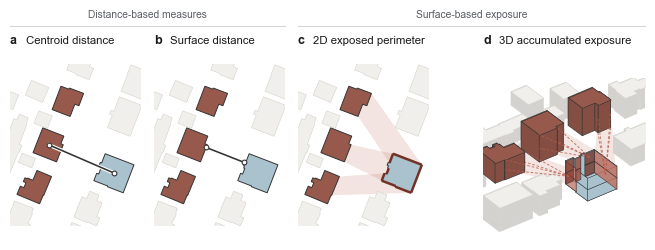

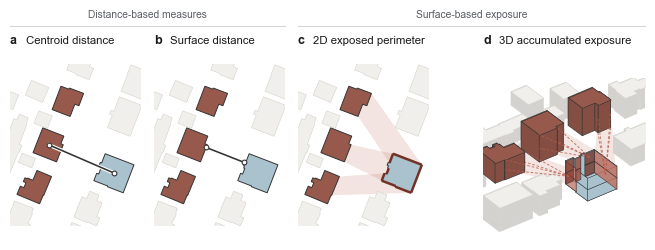

In [10]:
# Figure 1a-d: one scene, four measures. Distance-based in a-b, surface-based
# exposure in c-d; panel d extrudes the footprints drawn in a-c.
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

import importlib

import src.viz.figure1_measures
import src.viz.figure1_perimeter_2d

for module in (src.viz.figure1_perimeter_2d, src.viz.figure1_measures):
    importlib.reload(module)

from src.viz.figure1_composite import FIG_RC, INK, MM
from src.viz.figure1_measures import (
    PANEL_TITLES, draw_measure_row, load_measure_scene,
)

WIDTH, HEIGHT = 180 * MM, 74 * MM
PANEL_BOTTOM, PANEL_HEIGHT, GAP, LEFT = .52, 1.62, .13, .16
widths = np.array([1., 1., 1., 1.87])
widths *= (WIDTH - 2 * LEFT - 3 * GAP) / widths.sum()
lefts = LEFT + np.concatenate([[0], np.cumsum(widths[:-1] + GAP)])

measure_scene = load_measure_scene(
    OPENVIEW_3D_RUN, BUILDING_CACHE, ANALYSIS_PATH,
    PACKAGE_ROOT / 'data' / 'derived' / 'openview2d_eaton_scene',
    receiver_id=receiver_id, source_id=street_emitter_id,
    plan_aspect=widths[0] / PANEL_HEIGHT, patch_run=OPENVIEW_PATCH_RUN,
)

with plt.rc_context(FIG_RC):
    fig_perimeter = plt.figure(figsize=(WIDTH, HEIGHT))
    axes = [fig_perimeter.add_axes(
        [left / WIDTH, (PANEL_BOTTOM - (.14 if index == 3 else 0)) / HEIGHT,
         width / WIDTH, PANEL_HEIGHT / HEIGHT],
        **({'projection': '3d', 'computed_zorder': False} if index == 3 else {}))
        for index, (left, width) in enumerate(zip(lefts, widths))]
    draw_measure_row(axes, measure_scene,
                     frame_aspect=widths[3] / PANEL_HEIGHT)

    panel_top = PANEL_BOTTOM + PANEL_HEIGHT
    for ax, letter, heading in zip(axes, 'abcd', PANEL_TITLES):
        x = ax.get_position().x0
        fig_perimeter.text(x, (panel_top + .20) / HEIGHT, letter, fontsize=9,
                           fontweight='bold', color=INK, va='baseline')
        fig_perimeter.text(x + .022, (panel_top + .20) / HEIGHT, heading,
                           fontsize=8.2, color=INK, va='baseline')
    for group, columns in (('Distance-based measures', (0, 1)),
                           ('Surface-based exposure', (2, 3))):
        start = axes[columns[0]].get_position().x0
        end = axes[columns[1]].get_position().x1
        fig_perimeter.text((start + end) / 2, (panel_top + .46) / HEIGHT, group,
                           fontsize=7.4, color='#5A5E63', ha='center',
                           va='baseline')
        fig_perimeter.add_artist(Line2D(
            [start, end], [(panel_top + .38) / HEIGHT] * 2, color='#C9CBCD',
            lw=.6, transform=fig_perimeter.transFigure))
    save_figure(fig_perimeter, 'measure_row_two_dimensional_exposure',
                'exploratory', tight=False)

display(measure_scene.summary.T.rename(columns={0: 'value'}))
fig_perimeter